In [1]:
print("Hello World")

Hello World


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.optimize import curve_fit

In [4]:
df = pd.read_csv('example_data_1_PHYS_433_533.csv')

In [5]:
print(df)

      f_res  max_power_dBm
0      3000          -54.0
1      3002          -54.1
2      3004          -54.0
3      3006          -53.9
4      3008          -53.8
...     ...            ...
996    4992          -63.8
997    4994          -63.3
998    4996          -63.3
999    4998          -63.8
1000   5000          -64.2

[1001 rows x 2 columns]


In [6]:
df

,f_res,max_power_dBm
0,3000,-54.0
1,3002,-54.1
2,3004,-54.0
3,3006,-53.9
4,3008,-53.8
...,...,...
996,4992,-63.8
997,4994,-63.3
998,4996,-63.3
999,4998,-63.8


In [7]:
frequency = df['f_res']
power_dBM = df['max_power_dBm']

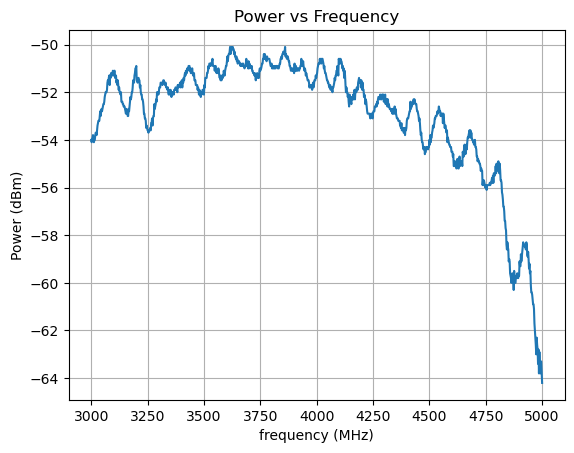

In [9]:
plt.plot(frequency,power_dBM)



plt.xlabel("frequency (MHz)")
plt.ylabel("Power (dBm)")
plt.title("Power vs Frequency")
# plt.legend()
plt.grid(True)
plt.show()

In [20]:
power_mW= 10**(np.array(power_dBM)/10)

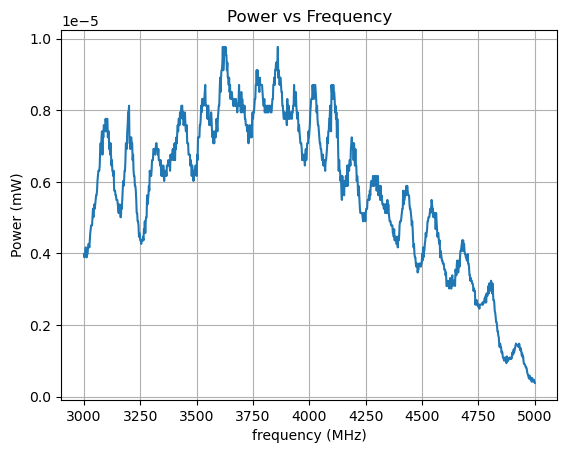

In [16]:
plt.plot(frequency,power_mW)



plt.xlabel("frequency (MHz)")
plt.ylabel("Power (mW)")
plt.title("Power vs Frequency")
# plt.legend()
plt.grid(True)
plt.show()

In [21]:
mask = frequency >4000
dfmask= df[mask]
frequency_filtered = frequency[mask]
power_mW_filtered = power_mW[mask]

In [18]:
dfmask

,f_res,max_power_dBm
501,4002,-51.2
502,4004,-51.0
503,4006,-50.9
504,4008,-50.8
505,4010,-50.8
...,...,...
996,4992,-63.8
997,4994,-63.3
998,4996,-63.3
999,4998,-63.8


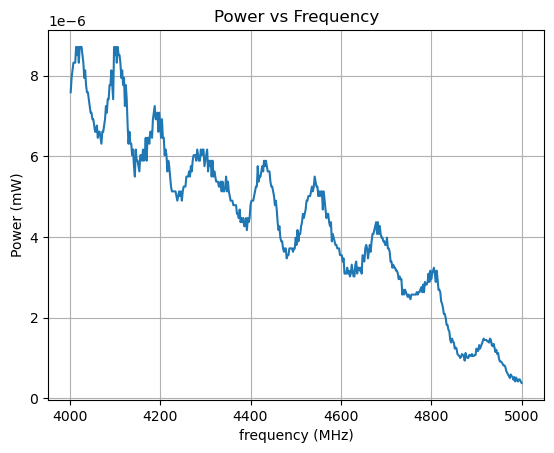

In [22]:
plt.plot(frequency_filtered,power_mW_filtered)



plt.xlabel("frequency (MHz)")
plt.ylabel("Power (mW)")
plt.title("Power vs Frequency")
# plt.legend()
plt.grid(True)
plt.show()

In [23]:
def linear_fit(x,m,b):
    return m*x+b



In [24]:
popt,pcov = curve_fit(linear_fit,frequency_filtered,power_mW_filtered, p0=[-1,4e-5]) #p0=guess for [slope,b at 0 not 4000]

In [25]:
popt #[slope,b]

array([-6.93853653e-09,  3.55731201e-05])

In [26]:
pcov #diagonal tells us how good fit is [ab/cd] where a= mslope goodness, d=b goodness

array([[ 9.43181768e-21, -4.24526116e-17],
       [-4.24526116e-17,  1.91865187e-13]])

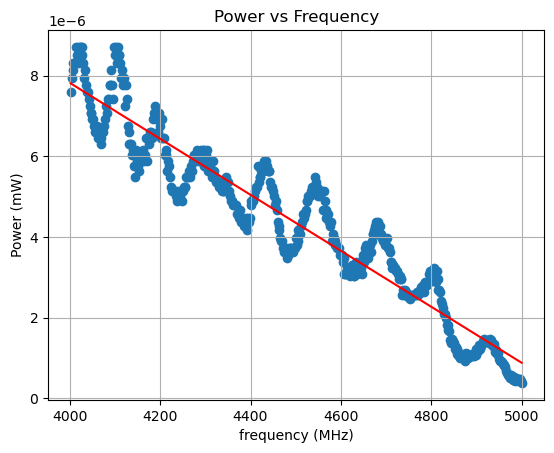

In [27]:
plt.scatter(frequency_filtered,power_mW_filtered)

plt.plot(frequency_filtered,linear_fit(frequency_filtered, popt[0],popt[1]),color='red')


plt.xlabel("frequency (MHz)")
plt.ylabel("Power (mW)")
plt.title("Power vs Frequency")
# plt.legend()
plt.grid(True)
plt.show()